In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
data = pd.read_csv("D:\Project\AI_learning\housing.csv")
print("数据加载完成")
print("数据形状：" + str(data.shape))
print("数据列名：" + str(list(data.columns)))
# 选择单个特征进行演示（使用median_income）
# median_income通常是与房价相关性最强的特征
feature_name = 'median_income'
# 准备数据
X_single = data[feature_name].values.reshape(-1, 1)  # 特征：变成列向量
y_single = data['median_house_value'].values         # 目标值
print("使用特征：" + feature_name)
print("数据形状：X=" + str(X_single.shape) + ", y=" + str(y_single.shape))

数据加载完成
数据形状：(20640, 10)
数据列名：['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']
使用特征：median_income
数据形状：X=(20640, 1), y=(20640,)


In [8]:
print("数据标准化")
# 标准化特征（便于梯度下降）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_single)
print("特征标准化完成")
print("标准化后特征均值：" + str(round(X_scaled.mean(), 6)) + " (应接近0)")
print("标准化后特征标准差：" + str(round(X_scaled.std(), 6)) + " (应接近1)")
# 为了可视化效果更好，也标准化目标值
# 注意：实际应用中通常不标准化目标值，这里为了演示方便
y_mean = y_single.mean()
y_std = y_single.std()
y_scaled = (y_single - y_mean) / y_std
print("目标值标准化完成")
print("目标值均值：" + str(round(y_mean, 2)))
print("目标值标准差：" + str(round(y_std, 2)))

数据标准化
特征标准化完成
标准化后特征均值：0.0 (应接近0)
标准化后特征标准差：1.0 (应接近1)
目标值标准化完成
目标值均值：206855.82
目标值标准差：115392.82


In [4]:
print("获取最优参数参考")
# 用sklearn找到最优参数作为参考点
model = LinearRegression()
model.fit(X_scaled, y_scaled)
w_optimal = model.coef_[0]    # 最优权重（斜率）
b_optimal = model.intercept_  # 最优偏置（截距）
print("sklearn线性回归结果：")
print("最优权重 w = " + str(round(w_optimal, 4)))
print("最优偏置 b = " + str(round(b_optimal, 4)))
# 计算最优成本（后面会用到）
def compute_cost(w, b, X, y):
    """
    计算单特征线性回归的成本（均方误差）
    """
    m = len(X)
    predictions = w * X.flatten() + b
    cost = np.mean((predictions - y) ** 2)
    return cost
optimal_cost = compute_cost(w_optimal, b_optimal, X_scaled, y_scaled)
print("最优成本 = " + str(round(optimal_cost, 4)))

获取最优参数参考
sklearn线性回归结果：
最优权重 w = 0.6881
最优偏置 b = -0.0
最优成本 = 0.5266


In [9]:
print("创建参数网格")
# 创建参数网格（以最优值为中心）
w_range = 2.0  # 权重的探索范围
b_range = 1.0  # 偏置的探索范围
# 生成网格点
w_values = np.linspace(w_optimal - w_range, w_optimal + w_range, 50)
b_values = np.linspace(b_optimal - b_range, b_optimal + b_range, 50)
# 创建网格
W, B = np.meshgrid(w_values, b_values)
print("权重w网格：" + str(len(w_values)) + "个点")
print("权重范围：[" + str(round(w_values.min(), 2)) + ", " + str(round(w_values.max(), 2)) + "]")
print("偏置b网格：" + str(len(b_values)) + "个点")
print("偏置范围：[" + str(round(b_values.min(), 2)) + ", " + str(round(b_values.max(), 2)) + "]")
# 计算每个网格点的成本
print("计算网格点成本...")
Z = np.zeros_like(W)
for i in range(len(b_values)):
    for j in range(len(w_values)):
        Z[i, j] = compute_cost(W[i, j], B[i, j], X_scaled, y_scaled)
print("成本计算完成")
print("最小成本：" + str(round(Z.min(), 4)))
print("最大成本：" + str(round(Z.max(), 4)))

创建参数网格
权重w网格：50个点
权重范围：[-1.31, 2.69]
偏置b网格：50个点
偏置范围：[-1.0, 1.0]
计算网格点成本...
成本计算完成
最小成本：0.5286
最大成本：5.5266


绘制3D成本函数曲面图
生成3D曲面图...


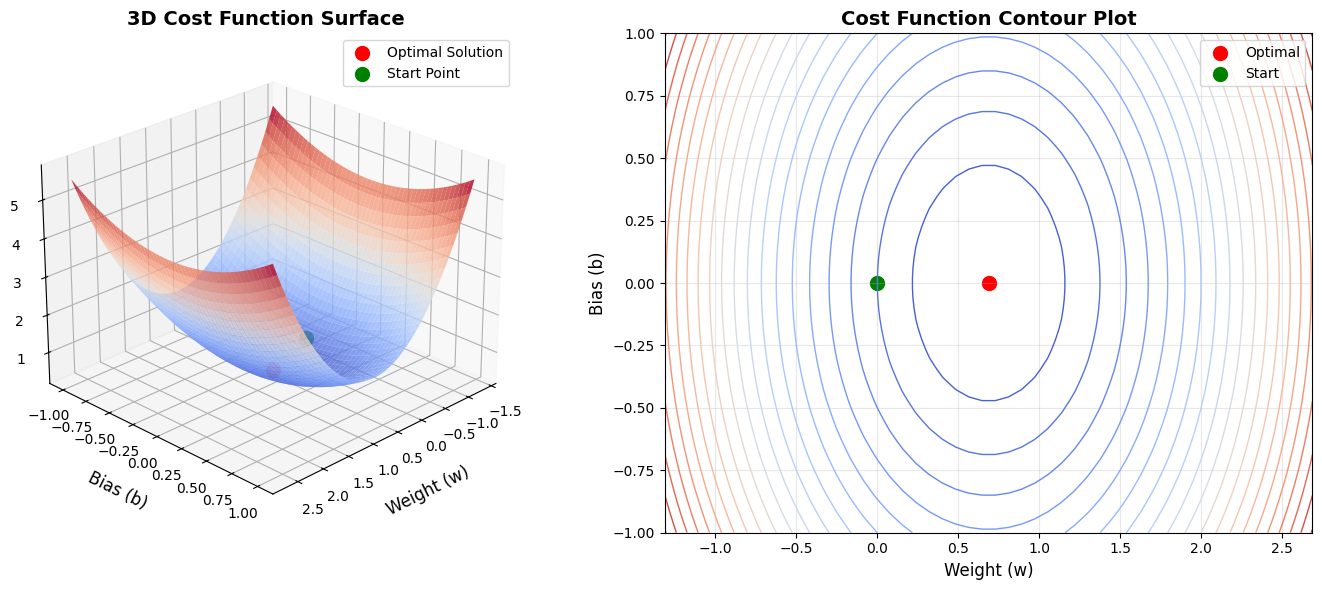

3D曲面图和等高线图显示完成


In [10]:
print("绘制3D成本函数曲面图")
print("生成3D曲面图...")
fig = plt.figure(figsize=(14, 6))
# 1. 3D曲面图
ax1 = fig.add_subplot(121, projection='3d')
# 绘制曲面
surf = ax1.plot_surface(W, B, Z, cmap='coolwarm', 
                       linewidth=0, antialiased=True, alpha=0.8)
# 标记最优解
ax1.scatter(w_optimal, b_optimal, optimal_cost, 
           color='red', s=100, label='Optimal Solution')
# 标记起点（w=0, b=0）
start_cost = compute_cost(0, 0, X_scaled, y_scaled)
ax1.scatter(0, 0, start_cost, color='green', s=100, label='Start Point')
# 设置标签
ax1.set_xlabel('Weight (w)', fontsize=12, labelpad=10)
ax1.set_ylabel('Bias (b)', fontsize=12, labelpad=10)
ax1.set_zlabel('Cost (MSE)', fontsize=12, labelpad=10)
ax1.set_title('3D Cost Function Surface', fontsize=14, fontweight='bold')
ax1.legend()
# 设置视角
ax1.view_init(elev=25, azim=45)
# 2. 等高线图
ax2 = fig.add_subplot(122)
# 绘制等高线
contour = ax2.contour(W, B, Z, 20, cmap='coolwarm', linewidths=1)
# 标记最优解
ax2.scatter(w_optimal, b_optimal, color='red', s=100, 
           label='Optimal')
# 标记起点
ax2.scatter(0, 0, color='green', s=100, label='Start')
# 设置标签
ax2.set_xlabel('Weight (w)', fontsize=12)
ax2.set_ylabel('Bias (b)', fontsize=12)
ax2.set_title('Cost Function Contour Plot', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("3D曲面图和等高线图显示完成")

In [6]:
print("实现梯度下降算法")
def gradient_descent(X, y, w_init=0, b_init=0, learning_rate=0.1, iterations=15):
    """
    执行梯度下降算法
    """
    # 初始化
    w = w_init
    b = b_init
    m = len(X)
    # 存储历史
    w_history = [w]
    b_history = [b]
    cost_history = [compute_cost(w, b, X, y)]
    print("开始梯度下降")
    print("学习率：" + str(learning_rate))
    print("迭代次数：" + str(iterations))
    print("初始参数：w=" + str(round(w, 4)) + ", b=" + str(round(b, 4)))
    print("初始成本：" + str(round(cost_history[0], 4)))
    print("-" * 40) 
    # 梯度下降迭代
    for i in range(iterations):
        # 计算预测值
        predictions = w * X.flatten() + b
        # 计算误差
        errors = predictions - y
        # 计算梯度（均方误差的导数）
        dw = (2/m) * np.dot(X.flatten(), errors)  # 权重梯度
        db = (2/m) * np.sum(errors)               # 偏置梯度
        # 更新参数
        w = w - learning_rate * dw
        b = b - learning_rate * db
        # 记录历史
        w_history.append(w)
        b_history.append(b)
        cost_history.append(compute_cost(w, b, X, y))
        # 每5次迭代显示一次进度
        if (i+1) % 5 == 0:
            print("迭代 " + str(i+1) + ": w=" + str(round(w, 4)) + 
                  ", b=" + str(round(b, 4)) + ", cost=" + str(round(cost_history[-1], 4)))  
    print("-" * 40)
    print("最终参数：w=" + str(round(w, 4)) + ", b=" + str(round(b, 4)))
    print("最终成本：" + str(round(cost_history[-1], 4)))  
    cost_reduction = (cost_history[0] - cost_history[-1]) / cost_history[0] * 100
    print("成本下降：" + str(round(cost_reduction, 1)) + "%")    
    return np.array(w_history), np.array(b_history), np.array(cost_history)
# 执行梯度下降
learning_rate = 0.2
iterations = 15
w_path, b_path, cost_path = gradient_descent(
    X_scaled, y_scaled, 
    w_init=0, b_init=0, 
    learning_rate=learning_rate, 
    iterations=iterations
)

实现梯度下降算法
开始梯度下降
学习率：0.2
迭代次数：15
初始参数：w=0, b=0
初始成本：1.0
----------------------------------------
迭代 5: w=0.6346, b=-0.0, cost=0.5294
迭代 10: w=0.6839, b=-0.0, cost=0.5266
迭代 15: w=0.6878, b=-0.0, cost=0.5266
----------------------------------------
最终参数：w=0.6878, b=-0.0
最终成本：0.5266
成本下降：47.3%


绘制梯度下降路径
生成可视化图表...


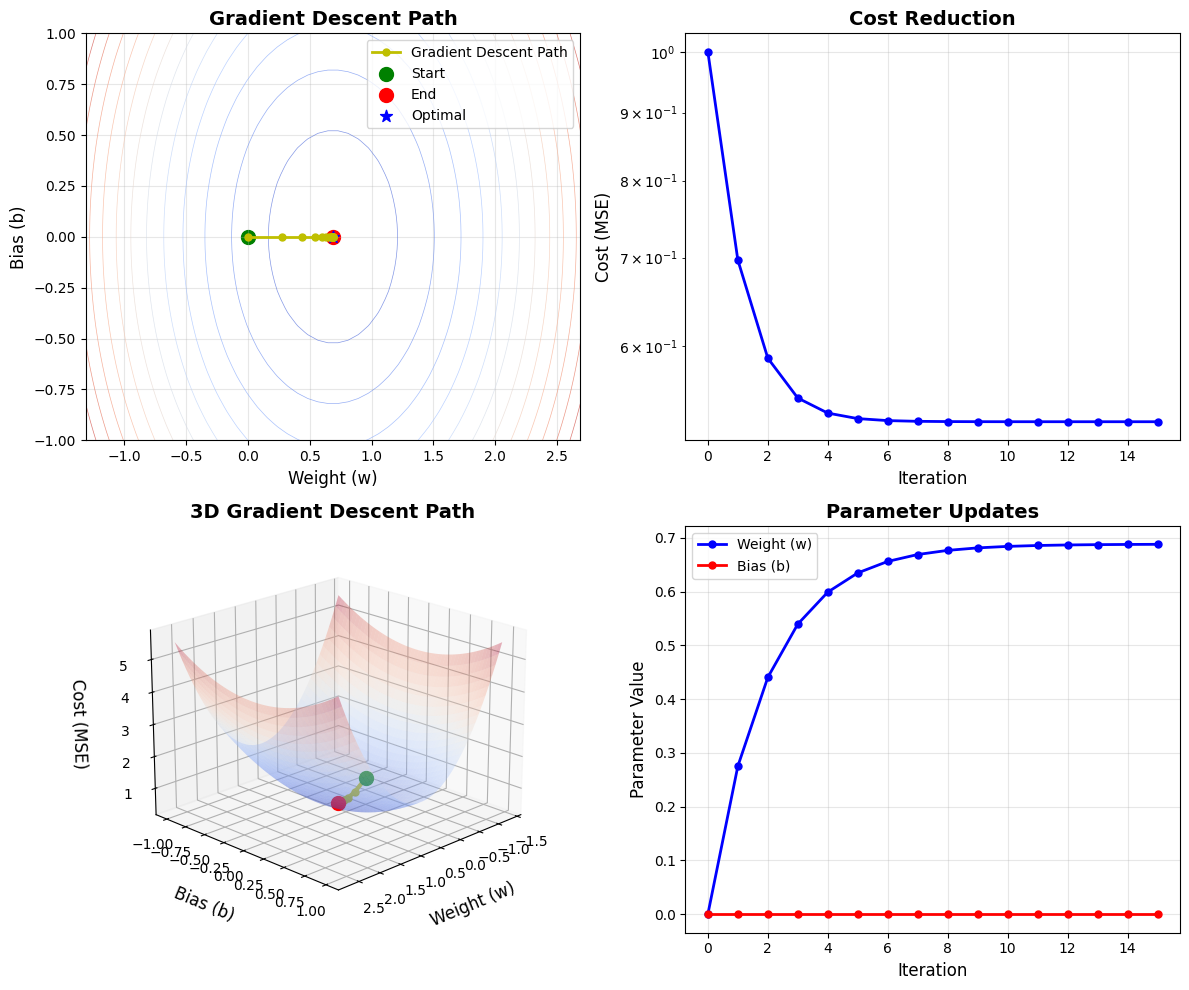

In [7]:
print("绘制梯度下降路径")
print("生成可视化图表...")
plt.figure(figsize=(12, 10))
# 1. 等高线图 + 梯度下降路径
plt.subplot(2, 2, 1) #subplot将画布分割成多个部分
contour = plt.contour(W, B, Z, 15, cmap='coolwarm', linewidths=0.5, alpha=0.7)
#w，b定义二维网格的x，y，z是高度值，cmap是颜色映射，等高线渐变，，alpha透明度。
# 绘制梯度下降路径
plt.plot(w_path, b_path, 'yo-', linewidth=2, markersize=5, 
        label='Gradient Descent Path')
# 标记起点和终点
plt.scatter(w_path[0], b_path[0], color='green', s=100, 
           label='Start')
plt.scatter(w_path[-1], b_path[-1], color='red', s=100, 
           label='End')
plt.scatter(w_optimal, b_optimal, color='blue', s=80, marker='*',
           label='Optimal')
plt.xlabel('Weight (w)', fontsize=12)
plt.ylabel('Bias (b)', fontsize=12)
plt.title('Gradient Descent Path', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
# 2. 成本下降曲线
plt.subplot(2, 2, 2)
plt.plot(range(len(cost_path)), cost_path, 'b-o', linewidth=2, markersize=5)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost (MSE)', fontsize=12)
plt.title('Cost Reduction', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')
# 3. 3D路径图
ax3d = plt.subplot(2, 2, 3, projection='3d')
# 绘制曲面
ax3d.plot_surface(W, B, Z, cmap='coolwarm', alpha=0.3, linewidth=0)
# 计算路径上的成本
path_costs = np.array([compute_cost(w, b, X_scaled, y_scaled) 
                      for w, b in zip(w_path, b_path)])
# 绘制路径
ax3d.plot(w_path, b_path, path_costs, 'yo-', linewidth=3, markersize=5)
# 标记点
ax3d.scatter(w_path[0], b_path[0], path_costs[0], color='green', s=100)
ax3d.scatter(w_path[-1], b_path[-1], path_costs[-1], color='red', s=100)
ax3d.set_xlabel('Weight (w)', fontsize=12, labelpad=10)
ax3d.set_ylabel('Bias (b)', fontsize=12, labelpad=10)
ax3d.set_zlabel('Cost (MSE)', fontsize=12, labelpad=10)
ax3d.set_title('3D Gradient Descent Path', fontsize=14, fontweight='bold')
ax3d.view_init(elev=20, azim=45)
# 4. 参数变化图
plt.subplot(2, 2, 4)
plt.plot(range(len(w_path)), w_path, 'b-o', linewidth=2, markersize=5, label='Weight (w)')
plt.plot(range(len(b_path)), b_path, 'r-o', linewidth=2, markersize=5, label='Bias (b)')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Parameter Value', fontsize=12)
plt.title('Parameter Updates', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()